# Homework 3: Download and analyze any data using tools you learned in class

### IMPORTANT: Save your notebook and files (if you import locally) 
### IMPORTANT: See my example data folder: data/hw/hw_3/cory-baird
### **HW Requirements**

- **Relative Paths Only**
  - Use relative paths from the project root (e.g., `data/hw/hw_3/student-name/data.csv`).
  - Never hardcode absolute paths specific to your local machine (e.g., `/Users/username/...`).
- **File Size Limit**
  - Any committed dataset must be reasonable in size (strictly under 10 megabytes).
    - If you have to filter the dataset (to make it smaller) and upload a smaller version

- **Dataset Selection**
  - Select a policy-relevant dataset with at least 50 observations (e.g., 50 states, countries, or time periods) for meaningful analysis.
  - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Data Acquisition**
  - You are highly encouraged to fetch data programmatically using an API (e.g. using `requests` with World Bank, US Census, or other public APIs) or load a direct public URL.

  - Alternatively, you may upload a local file, provided it is committed to your repository.
    - If you read csv/parquet etc use relative paths such as `data/hw/hw_3/student-name/data.csv`.
    - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Reproducibility**
  - Commit both this notebook and the dataset so that your grader can run all cells from top to bottom out-of-the-box.

## IMPORTANT

---
### **Objectives**
- Select, acquire, and load a policy-relevant dataset of your choice.
- Apply clean code principles (environment checks, Python collections, standardized variable naming).
- Preprocess and standardize columns using Pandas techniques.
- Programmatically merge your primary dataset with a secondary source.
- Segment your data and run custom aggregations (using groupby or custom grouping strategies).
- Create customized visualizations and run exploratory regression analysis to discover policy insights.

### **Concept Reference Map**
- **Data Acquisition**: APIs (`requests` library), reading Parquet/CSV (Week 2/3 basics, Week 4 `1-visualization_basics.ipynb`)
- **Data Manipulation**: Selecting, renaming columns, filtering (`query()`), dropping NaNs (Week 4 `1-visualization_basics.ipynb`)
- **Aggregation**: Groupby, descriptive statistics (`describe()`, `mean()`) (Week 4 `1-visualization_basics.ipynb`)
- **Data Merging**: Pandas `merge()` matching indices or keys (Week 4 `2-merging_practice.ipynb`)
- **Visualization**: Scatter plots, line/bar charts, customization (Week 4 / Week 6 `1-regression.ipynb`)
- **Modeling**: Simple Linear Regression (`statsmodels`), line of best fit (Week 6 `1-regression.ipynb`)

---

### **Part 1: Data Acquisition & Environment Preparation**

- **Environment Setup**
  - Use python's `os` library (as reviewed in Week 3) to print your current working directory (`os.getcwd()`) and list the files in your project directory (`os.listdir()`) to ensure your paths are configured correctly.
- **Acquisition Steps**
  - Programmatically fetch data using `requests` or read directly from a public URL using Pandas.
  - If loading a committed local dataset, load it using a relative path.
- **Code Requirements**
  - Define variables using standardized, descriptive names.
  - Keep all function and method arguments on a single line.
  - Do not use docstrings (`""" """`) or runtime type checking in your helper methods.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import statsmodels.api as sm


# 1. Print environment details (working directory and local folder contents)
project_root = Path.cwd()
while not (project_root / "README.md").exists() and project_root != project_root.parent:
    project_root = project_root.parent
os.chdir(project_root)

print("Current working directory:", os.getcwd())
print("Project directory files:", os.listdir())

# 2. Acquire and load your primary dataset
student_data_dir = Path("data/hw/hw_3/wu-cheng")
student_data_dir.mkdir(parents=True, exist_ok=True)

def fetch_world_bank_indicator(indicator_code, start_year, end_year):
    api_url = f"https://api.worldbank.org/v2/country/all/indicator/{indicator_code}?format=json&per_page=20000&date={start_year}:{end_year}"
    response = requests.get(api_url, timeout=30)
    response.raise_for_status()
    payload = response.json()
    if len(payload) < 2 or not payload[1]:
        raise ValueError(f"No World Bank records returned for {indicator_code}")
    indicator_data = pd.json_normalize(payload[1])
    return indicator_data

analysis_year = 2022
life_indicator_code = "SP.DYN.LE00.IN"
life_raw = fetch_world_bank_indicator(life_indicator_code, analysis_year, analysis_year)
life_raw_path = student_data_dir / "raw_life_expectancy_2022.csv"
life_raw.to_csv(life_raw_path, index=False)
print("Saved primary dataset to:", life_raw_path)
life_raw.head()


Current working directory: /home/wucheng/datascience-publicpolicy-2026
Project directory files: ['data', '.venv', '.claude', 'uv.lock', '.gitignore', 'pyproject.toml', 'notebooks', 'requirements.txt', 'README.md', '.codex', '.git', 'environment.yml']
Saved primary dataset to: data/hw/hw_3/wu-cheng/raw_life_expectancy_2022.csv


,countryiso3code,date,value,unit,obs_status,decimal,indicator.id,indicator.value,country.id,country.value
0,AFE,2022,64.487152,,,0,SP.DYN.LE00.IN,"Life expectancy at birth, total (years)",ZH,Africa Eastern and Southern
1,AFW,2022,57.987850,,,0,SP.DYN.LE00.IN,"Life expectancy at birth, total (years)",ZI,Africa Western and Central
2,ARB,2022,71.876096,,,0,SP.DYN.LE00.IN,"Life expectancy at birth, total (years)",1A,Arab World
3,CSS,2022,72.832292,,,0,SP.DYN.LE00.IN,"Life expectancy at birth, total (years)",S3,Caribbean small states
4,CEB,2022,76.652299,,,0,SP.DYN.LE00.IN,"Life expectancy at birth, total (years)",B8,Central Europe and the Baltics


### **Dataset Context & Relevance**

- **Dataset Source**
  - Specify the source of your dataset (e.g., API name, public organization, or website URL).

- **Source:** World Bank World Development Indicators API, indicator `SP.DYN.LE00.IN`.
- **Dataset:** Life expectancy at birth, total (years), for 2022.
- **Policy relevance:** Life expectancy summarizes population health and is often used to compare public health systems, economic development, safety, nutrition, and environmental conditions across countries.
- **API URL pattern:** `https://api.worldbank.org/v2/country/all/indicator/SP.DYN.LE00.IN?format=json&per_page=20000&date=2022:2022`

### **Part 2: Data Cleaning & Preprocessing**

- **Data Inspection**
  - Inspect column names, data types, and non-null counts using `.info()` and `.head()`.
- **Preprocessing Tasks**
  - Select a subset of columns necessary for your policy inquiry.
  - Standardize column names to a clean formatting (preferably `snake_case` or another consistent style).
  - Identify and handle missing values (`NaN`s) by dropping or filling them.
- **Python Grammar Tip**
  - You are encouraged to use a Python dictionary (as reviewed in Week 2 & 3) to map and rename your column names cleanly.

In [2]:
# 1. Inspect data structure using pandas methods
life_raw.info()
life_raw.head()


<class 'pandas.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   countryiso3code  266 non-null    str    
 1   date             266 non-null    str    
 2   value            265 non-null    float64
 3   unit             266 non-null    str    
 4   obs_status       266 non-null    str    
 5   decimal          266 non-null    int64  
 6   indicator.id     266 non-null    str    
 7   indicator.value  266 non-null    str    
 8   country.id       266 non-null    str    
 9   country.value    266 non-null    str    
dtypes: float64(1), int64(1), str(8)
memory usage: 40.3 KB


,countryiso3code,date,value,unit,obs_status,decimal,indicator.id,indicator.value,country.id,country.value
0,AFE,2022,64.487152,,,0,SP.DYN.LE00.IN,"Life expectancy at birth, total (years)",ZH,Africa Eastern and Southern
1,AFW,2022,57.987850,,,0,SP.DYN.LE00.IN,"Life expectancy at birth, total (years)",ZI,Africa Western and Central
2,ARB,2022,71.876096,,,0,SP.DYN.LE00.IN,"Life expectancy at birth, total (years)",1A,Arab World
3,CSS,2022,72.832292,,,0,SP.DYN.LE00.IN,"Life expectancy at birth, total (years)",S3,Caribbean small states
4,CEB,2022,76.652299,,,0,SP.DYN.LE00.IN,"Life expectancy at birth, total (years)",B8,Central Europe and the Baltics


In [3]:
# 2. Rename columns and select a clean subset
life_column_map = {
    "countryiso3code": "country_code",
    "country.value": "country_name",
    "date": "year",
    "value": "life_expectancy"
}

life_expectancy = life_raw[list(life_column_map.keys())].rename(columns=life_column_map)
life_expectancy["year"] = life_expectancy["year"].astype(int)
life_expectancy.head()


,country_code,country_name,year,life_expectancy
0,AFE,Africa Eastern and Southern,2022,64.487152
1,AFW,Africa Western and Central,2022,57.987850
2,ARB,Arab World,2022,71.876096
3,CSS,Caribbean small states,2022,72.832292
4,CEB,Central Europe and the Baltics,2022,76.652299


In [4]:
# 3. Filter row or column filters if necessary
life_expectancy = life_expectancy.query("year == @analysis_year").copy()
life_expectancy = life_expectancy.query("country_code != ''").copy()
life_expectancy.shape


(261, 4)

In [5]:
# 4. Handle missing values (NaNs) if necessary
life_expectancy_clean = life_expectancy.dropna(subset=["life_expectancy"]).copy()
print("Rows before dropping missing life expectancy:", len(life_expectancy))
print("Rows after dropping missing life expectancy:", len(life_expectancy_clean))
life_expectancy_clean.head()


Rows before dropping missing life expectancy: 261
Rows after dropping missing life expectancy: 261


,country_code,country_name,year,life_expectancy
0,AFE,Africa Eastern and Southern,2022,64.487152
1,AFW,Africa Western and Central,2022,57.987850
2,ARB,Arab World,2022,71.876096
3,CSS,Caribbean small states,2022,72.832292
4,CEB,Central Europe and the Baltics,2022,76.652299


### **Part 3: Merging Datasets**

- **Secondary Source Selection**
  - Programmatically download/read another related dataset.
- **Clean & Standardize**
  - Preprocess and rename the columns of the secondary dataset.
- **Merging Process**
  - Merge both datasets on a common key (such as country code or year).
  - Display the shape and head of your merged dataset to verify that the join was successful.

In [6]:
# 1. Load and clean the secondary dataset
gdp_indicator_code = "NY.GDP.PCAP.CD"
gdp_raw = fetch_world_bank_indicator(gdp_indicator_code, analysis_year, analysis_year)
gdp_raw_path = student_data_dir / "raw_gdp_per_capita_2022.csv"
gdp_raw.to_csv(gdp_raw_path, index=False)

gdp_column_map = {
    "countryiso3code": "country_code",
    "country.value": "country_name",
    "date": "year",
    "value": "gdp_per_capita"
}

gdp_per_capita = gdp_raw[list(gdp_column_map.keys())].rename(columns=gdp_column_map)
gdp_per_capita["year"] = gdp_per_capita["year"].astype(int)
gdp_per_capita_clean = gdp_per_capita.dropna(subset=["gdp_per_capita"]).query("country_code != ''").copy()

country_metadata_url = "https://api.worldbank.org/v2/country?format=json&per_page=400"
country_response = requests.get(country_metadata_url, timeout=30)
country_response.raise_for_status()
country_metadata_raw = pd.json_normalize(country_response.json()[1])
country_metadata_path = student_data_dir / "country_metadata.csv"
country_metadata_raw.to_csv(country_metadata_path, index=False)

metadata_column_map = {
    "id": "country_code",
    "name": "country_name_metadata",
    "region.value": "region",
    "incomeLevel.value": "income_group"
}

country_metadata = country_metadata_raw[list(metadata_column_map.keys())].rename(columns=metadata_column_map)
country_metadata = country_metadata.query("region != 'Aggregates'").copy()
print("Saved secondary dataset to:", gdp_raw_path)
gdp_per_capita_clean.head()


Saved secondary dataset to: data/hw/hw_3/wu-cheng/raw_gdp_per_capita_2022.csv


,country_code,country_name,year,gdp_per_capita
0,AFE,Africa Eastern and Southern,2022,1679.327622
1,AFW,Africa Western and Central,2022,2138.473153
2,ARB,Arab World,2022,7950.355820
3,CSS,Caribbean small states,2022,17456.308485
4,CEB,Central Europe and the Baltics,2022,19530.155323


In [7]:
# 2. Merge your datasets on a common key
merged_data = life_expectancy_clean.merge(gdp_per_capita_clean[["country_code", "year", "gdp_per_capita"]], on=["country_code", "year"], how="inner")
merged_data = merged_data.merge(country_metadata, on="country_code", how="inner")
merged_data = merged_data.dropna(subset=["life_expectancy", "gdp_per_capita", "income_group"]).copy()
merged_data = merged_data.query("gdp_per_capita > 0").copy()
merged_data["log_gdp_per_capita"] = np.log(merged_data["gdp_per_capita"])
print("Merged dataset shape:", merged_data.shape)
merged_data.head()


Merged dataset shape: (209, 9)


,country_code,country_name,year,life_expectancy,gdp_per_capita,country_name_metadata,region,income_group,log_gdp_per_capita
0,AFG,Afghanistan,2022,65.617,357.261153,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income,5.878467
1,ALB,Albania,2022,78.769,7756.961887,Albania,Europe & Central Asia,Upper middle income,8.956346
2,DZA,Algeria,2022,76.129,4960.303343,Algeria,"Middle East, North Africa, Afghanistan & Pakistan",Upper middle income,8.509222
3,ASM,American Samoa,2022,72.752,18017.458938,American Samoa,East Asia & Pacific,High income,9.799097
4,AND,Andorra,2022,84.016,42414.047986,Andorra,Europe & Central Asia,High income,10.655235


### **Merge Verification**

- **Merge Key**
  - Describe the matching key you selected (e.g. country, state, year).
- **Observations Retained**
  - Specify how many matching rows were successfully kept after merging.

- **Merge key:** I matched the datasets using `country_code` and `year`, then merged World Bank country metadata using `country_code` to keep only individual countries and attach `region` and `income_group`.
- **Observations retained:** The merge keeps the countries that have non-missing 2022 values for both life expectancy and GDP per capita. The exact retained count is printed by `merged_data.shape` in the merge cell.

### **Part 4: Aggregation & Groupby Analysis**

- **Aggregation Task**
  - Segment your indicators using `.groupby()` to calculate descriptive metrics (such as `.mean()`, `.median()`, `.min()`, or `.max()`) across different categories.
- **Backup Strategies (If your dataset does not have natural multiple groups)**
  - If your dataset consists of only continuous variables, choose one of these backup strategies:
    - **Binning**: Use `pd.cut()` to partition a continuous variable into groups (e.g. splitting GDP per capita into low, medium, and high income groups).
    - **Threshold Filtering**: Segment your dataset into two groups based on a threshold (e.g. countries with life expectancy > 75 vs. <= 75).
    - **Dictionary Mapping**: Create a custom Python dictionary (as reviewed in Week 2 & 3) mapping continuous features to custom categories, and map/merge it into your DataFrame to create groups.

In [8]:
# Apply groupby aggregation or implement one of the backup grouping strategies
income_group_order = ["Low income", "Lower middle income", "Upper middle income", "High income"]
merged_data["income_group"] = pd.Categorical(merged_data["income_group"], categories=income_group_order, ordered=True)

income_group_summary = (
    merged_data.groupby("income_group", observed=True)
    .agg(
        country_count=("country_code", "nunique"),
        average_life_expectancy=("life_expectancy", "mean"),
        median_life_expectancy=("life_expectancy", "median"),
        median_gdp_per_capita=("gdp_per_capita", "median")
    )
    .reset_index()
)

income_group_summary


/tmp/ipykernel_937088/235177102.py:3: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  merged_data["income_group"] = pd.Categorical(merged_data["income_group"], categories=income_group_order, ordered=True)


,income_group,country_count,average_life_expectancy,median_life_expectancy,median_gdp_per_capita
0,Low income,21,60.840810,62.882,827.330843
1,Lower middle income,50,68.240516,67.611,2368.592796
2,Upper middle income,53,73.286978,73.973,6909.352818
3,High income,83,79.108559,80.487,35638.886946


Income groups show a clear public-policy gradient: countries in higher income categories tend to have longer average life expectancy. This does not prove income alone causes better health, but it suggests that fiscal capacity, infrastructure, education, health systems, and living conditions are closely connected to population survival outcomes.

### **Part 5: Visualization & Regression Modeling**

- **Visualization Requirements**
  - Generate at least two fully customized, beautiful Matplotlib plots.
  - **Plot 1**: A bar chart or line chart showing aggregated subgroups from Part 4.
  - **Plot 2**: A scatter plot representing the relationship between two primary indicators.
  - **Customizations**: Make sure to customize titles, axis labels, gridlines, colors, and markers for a clean and readable style.
- **Exploratory Modeling**
  - Fit a simple linear regression using `statsmodels` (Level-Level, Log-Level, or Log-Log as discussed in Week 6) to model the policy relationship.
  - Plot the line of best fit directly over your scatter plot.
  - Print the summary table and interpret the slope coefficient.

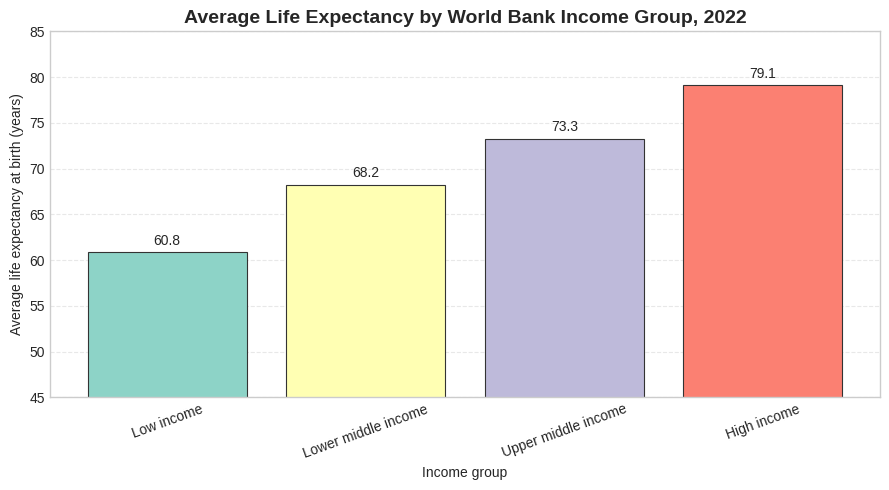

In [9]:
# Plot 1: Customized bar chart or line chart of aggregated subgroups
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ["#8dd3c7", "#ffffb3", "#bebada", "#fb8072"]

ax.bar(income_group_summary["income_group"].astype(str), income_group_summary["average_life_expectancy"], color=bar_colors, edgecolor="#333333", linewidth=0.8)
ax.set_title("Average Life Expectancy by World Bank Income Group, 2022", fontsize=14, fontweight="bold")
ax.set_xlabel("Income group")
ax.set_ylabel("Average life expectancy at birth (years)")
ax.set_ylim(45, 85)
ax.grid(axis="y", linestyle="--", alpha=0.45)
ax.grid(axis="x", visible=False)
ax.tick_params(axis="x", rotation=20)

for row_index, row in income_group_summary.iterrows():
    ax.text(row_index, row["average_life_expectancy"] + 0.8, f"{row['average_life_expectancy']:.1f}", ha="center", fontsize=10)

fig.tight_layout()
plt.show()


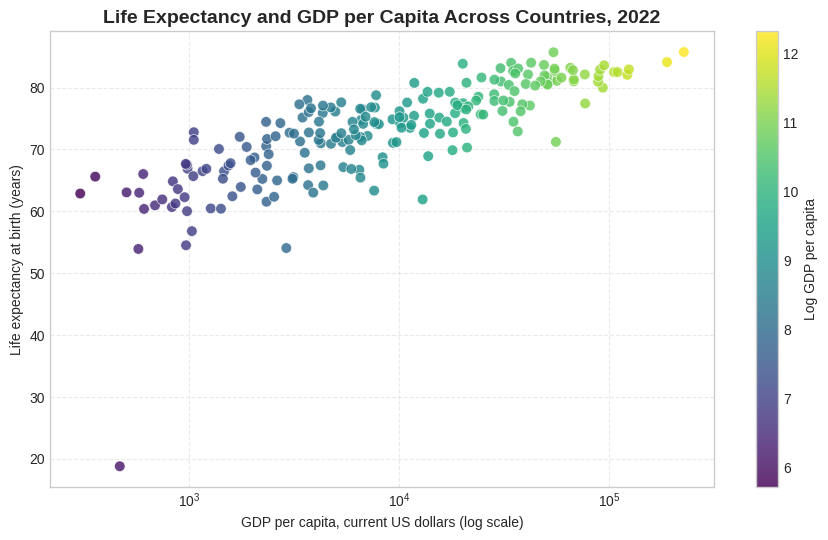

In [10]:
# Plot 2: Customized scatter plot of primary policy variables
fig, ax = plt.subplots(figsize=(9, 5.5))
scatter = ax.scatter(merged_data["gdp_per_capita"], merged_data["life_expectancy"], c=merged_data["log_gdp_per_capita"], cmap="viridis", s=58, alpha=0.82, edgecolor="white", linewidth=0.5)

ax.set_xscale("log")
ax.set_title("Life Expectancy and GDP per Capita Across Countries, 2022", fontsize=14, fontweight="bold")
ax.set_xlabel("GDP per capita, current US dollars (log scale)")
ax.set_ylabel("Life expectancy at birth (years)")
ax.grid(True, which="major", linestyle="--", alpha=0.4)
colorbar = fig.colorbar(scatter, ax=ax)
colorbar.set_label("Log GDP per capita")

fig.tight_layout()
plt.show()


                            OLS Regression Results                            
Dep. Variable:        life_expectancy   R-squared:                       0.627
Model:                            OLS   Adj. R-squared:                  0.625
Method:                 Least Squares   F-statistic:                     348.0
Date:                Tue, 23 Jun 2026   Prob (F-statistic):           3.24e-46
Time:                        20:28:19   Log-Likelihood:                -626.05
No. Observations:                 209   AIC:                             1256.
Df Residuals:                     207   BIC:                             1263.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 34.4224      2

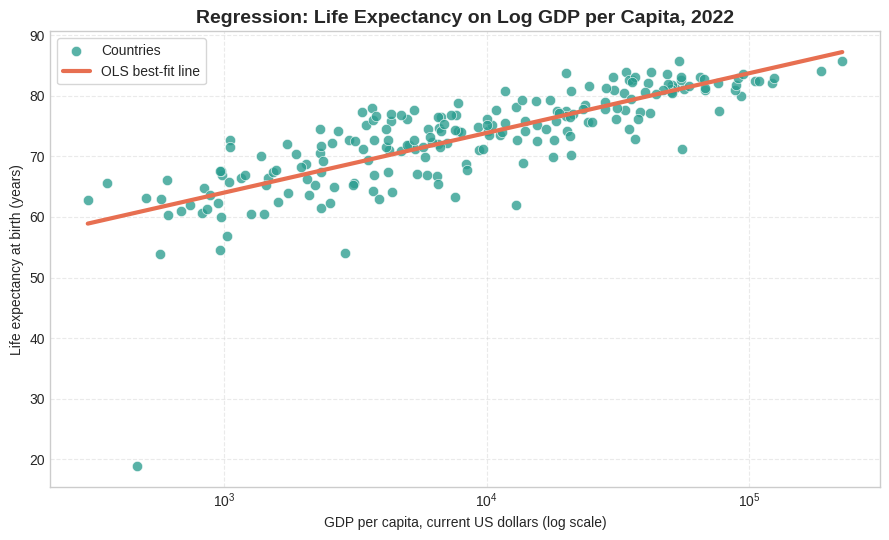

Slope interpretation: a 1% increase in GDP per capita is associated with about 0.043 additional years of life expectancy, on average, in this cross-country 2022 sample.


In [11]:
# Fit a simple linear regression and overlay the line of best fit
regression_data = merged_data[["life_expectancy", "log_gdp_per_capita", "gdp_per_capita"]].dropna().copy()
y = regression_data["life_expectancy"]
X = sm.add_constant(regression_data["log_gdp_per_capita"])
life_expectancy_model = sm.OLS(y, X).fit()
print(life_expectancy_model.summary())

x_line = np.linspace(regression_data["log_gdp_per_capita"].min(), regression_data["log_gdp_per_capita"].max(), 200)
prediction_frame = pd.DataFrame({"const": 1, "log_gdp_per_capita": x_line})
y_line = life_expectancy_model.predict(prediction_frame)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(regression_data["gdp_per_capita"], regression_data["life_expectancy"], color="#2a9d8f", s=55, alpha=0.78, edgecolor="white", linewidth=0.5, label="Countries")
ax.plot(np.exp(x_line), y_line, color="#e76f51", linewidth=3, label="OLS best-fit line")
ax.set_xscale("log")
ax.set_title("Regression: Life Expectancy on Log GDP per Capita, 2022", fontsize=14, fontweight="bold")
ax.set_xlabel("GDP per capita, current US dollars (log scale)")
ax.set_ylabel("Life expectancy at birth (years)")
ax.grid(True, which="major", linestyle="--", alpha=0.4)
ax.legend(frameon=True)
fig.tight_layout()
plt.show()

slope = life_expectancy_model.params["log_gdp_per_capita"]
print(f"Slope interpretation: a 1% increase in GDP per capita is associated with about {slope * 0.01:.3f} additional years of life expectancy, on average, in this cross-country 2022 sample.")


The scatter plot shows a positive but flattening relationship: increases in GDP per capita are associated with large life-expectancy differences among poorer and middle-income countries, while the relationship is less steep among richer countries. The log-level regression is therefore a reasonable exploratory model because each percentage change in GDP per capita is associated with a constant change in predicted life expectancy. The slope should be interpreted as correlation, not a causal effect, because many omitted policy and institutional factors also affect health outcomes.

### **Submission Checklist**

- **Out-of-the-Box Execution**
  - Select `Kernel -> Restart & Run All` to verify all cells run without error.
- **Reproducibility & Paths**
  - Verify that both the notebook and the dataset are saved and committed in Git.
  - Ensure all files are loaded using relative paths.
- **Visual Elements & Design**
  - Ensure all plots are fully customized, clearly labeled, and have titles.